# Predicting heart disease using machine learning

This notebook looks into using various Python-based machine learning and
data science libraries in an attempt to build a machine learning model
capable of predicting whether or not someone has heart disease based
on their medical attributes.

We'll take the following approach.

1. Problem definition
2. Data
3. lEvaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

In a statement

> Given clinical parameters about a patient, can we predict
> whether or not they have heart disease?

## 2. Data

We can consult [the original data set](https://archive.ics.uci.edu/dataset/45/heart+disease).

However, it is more convenient to consult [the same data set on Kaggle](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data).

Here is a data dictionary of the available data.

Column Descriptions:

1. id (Unique id for each patient)
2. age (Age of the patient in years)
3. origin (place of study)
4. sex (Male/Female)
5. cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
6. trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
7. chol (serum cholesterol in mg/dl)
8. fbs (if fasting blood sugar > 120 mg/dl)
9. restecg (resting electrocardiographic results)
   -- Values: [normal, stt abnormality, lv hypertrophy]
10. thalach: maximum heart rate achieved
11. exang: exercise-induced angina (True/ False)
12. oldpeak: ST depression induced by exercise relative to rest
13. slope: the slope of the peak exercise ST segment
14. ca: number of major vessels (0-3) colored by fluoroscopy
15. thal: [normal; fixed defect; reversible defect]
16. num: the predicted attribute

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a
> patient has heart disease during the proof of concept, we
> will pursue the project further.

## 4. Features

This is where you'll acquire different information about each of the fatures in your data.

**Create a data dictionary**

1. age - Age of the patient in years
2. sex - 1 = male; 0 = female
3. cp - chest pain type
    - Typical angina: chest pain related to decreased blood supply to the heart
    - Atypical angina: chest pain not related to the heart
    - Non-anginal: typical esophageal spasms (not heart related)
    - Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital)
   anything above 130-1490 is typically cause for concern
5. chol - serum cholesterol in mg/dl
    - Serum = LDL + HDL + 0.2 * triglycerides
    - About 200 is cause for concern
6. fbs - fasting blood sugar > 120 mg/dl: 1 = true; 0 = false)
    - '> 126' might signal diabetes
7. restecg (resting electrocardiographic results)
    - 0: Nothing to note
    - 1: ST-T Wave abnormality
    - 2: Left ventricular hypertrophy
8. thalach: maximum heart rate achieved
9. exang: exercise-induced angina (1 = yes; 0 = no)
10. oldpeak: ST depression (heart potentially not getting enough oxygen)
    induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    - 0: Upsloping
    - 1: Flatsloping
    - 2. Downsloping
12. ca: number of major vessels (0-3) colored by fluoroscopy
13. thal: Thalium stress result
    - 1: Normal
    - 3: Normal
    - 6: Fixed defect
    - 7: reversible defect
14. target: Have disease or not (1 = yes; 0 = no)

## Preparing the tools

We will use:

- `pandas`
- `matplotlib`
- `numpy`

For data analysis and manipulation

In [1]:
from calendar import LocaleTextCalendar

# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# %matplotlib inline

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# del Evaluations
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
)

### Load Data

In [2]:
df = pd.read_csv('data/heart-disease.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
df.shape

(303, 14)

## Data Exploration (exploratory data analysis or EDA)

The goal here is to find out more about the data and become
a subject-matter expert on the data set with which you are
working.

Steps

1. What question(s) are you trying to solve
2. What kind of data do we have and how do we treat different types?
3. What is missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change, or remove features to get more out of your data?

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
# Let's start by looking at the `target` variable (the "label")
# We'll find out how many items exist of each class
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

These results are fairly balanced between our two labels

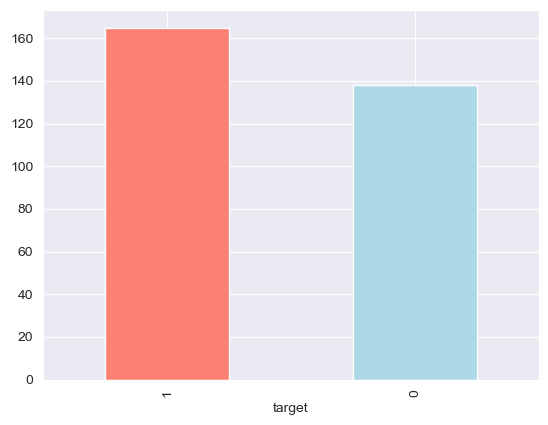

In [7]:
# Let's plot the `target` values
df['target'].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])
plt.show()

In [8]:
# What can we learn about other data?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# What data is missing?
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
# Additional descriptive information
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency According to Sex

Remember we are **exploring** the data

In [11]:
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# Compare target column with sex column
pd.crosstab(df['target'], df['sex'])

sex,0,1
target,,
0,24,114
1,72,93


In [13]:
heart_disease_count = len(df[df['target'] == 1])
participant_count = len(df)
heart_disease_count  / participant_count * 100

54.45544554455446

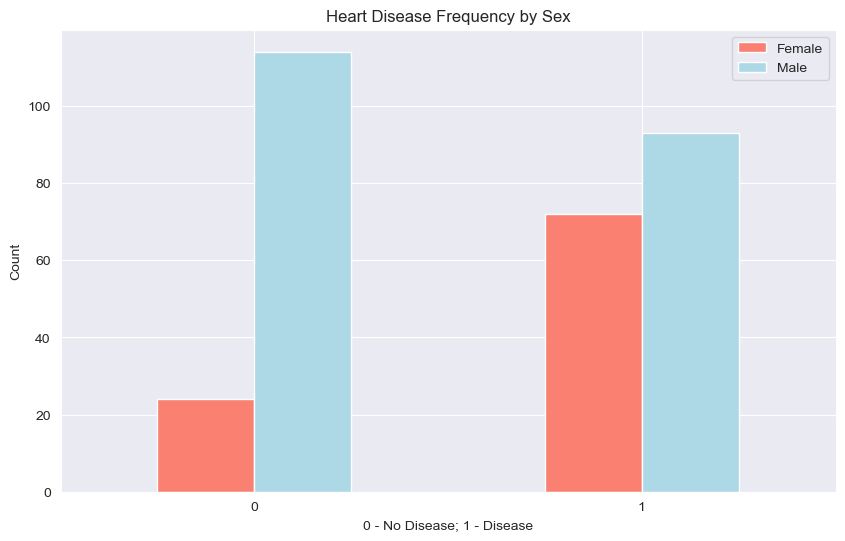

In [14]:
# Create a plot of our crosstab
pd.crosstab(df['target'], df['sex']).plot(kind='bar',
                                          figsize=(10, 6),
                                          color=['salmon', 'lightblue'])
plt.title('Heart Disease Frequency by Sex')
plt.xlabel('0 - No Disease; 1 - Disease')
plt.ylabel('Count')
plt.legend(['Female', 'Male'])
plt.xticks(rotation=0)
plt.show()

In [15]:
pd.crosstab(df['target'], df['cp'])

cp,0,1,2,3
target,,,,
0,104,9,18,7
1,39,41,69,16


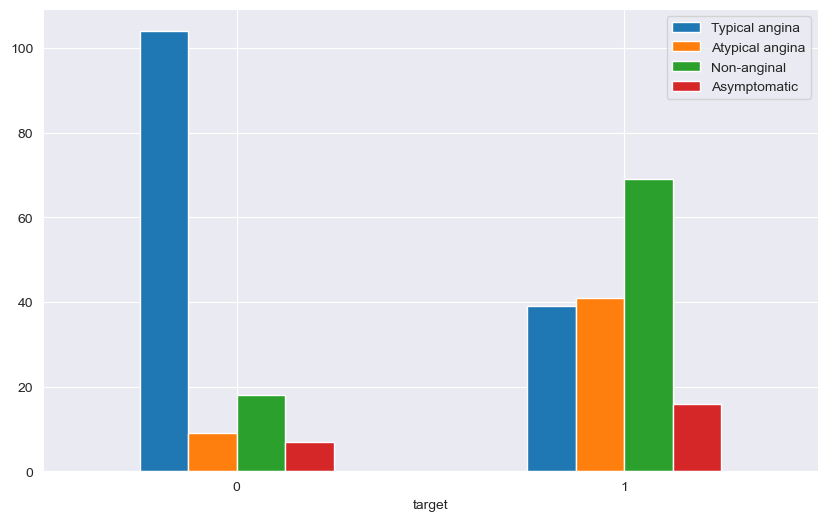

In [16]:
pd.crosstab(df['target'], df['cp']).plot(
    kind='bar',
    figsize=(10, 6),
)
plt.xticks(rotation=0)
plt.legend([
    'Typical angina',
    'Atypical angina',
    'Non-anginal',
    'Asymptomatic',
])
plt.show()

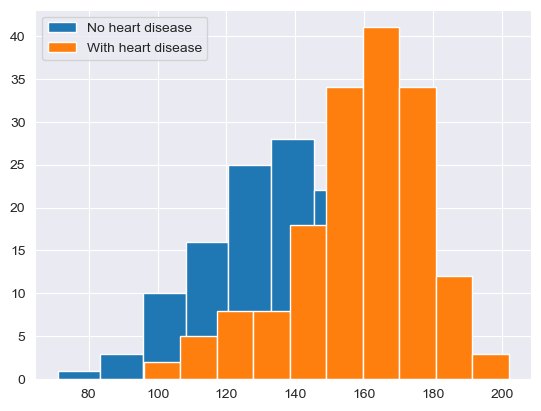

In [17]:
plt.hist(df[df['target'] == 0]['thalach'], label='No heart disease')
plt.hist(df[df['target'] == 1]['thalach'], label='With heart disease')
plt.legend()
plt.show()

In [18]:
# `thalach` is maximum heart rate achieved
df['thalach'].value_counts()

thalach
162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: count, Length: 91, dtype: int64

### Age versus Max Heart Rate for Heart Disease

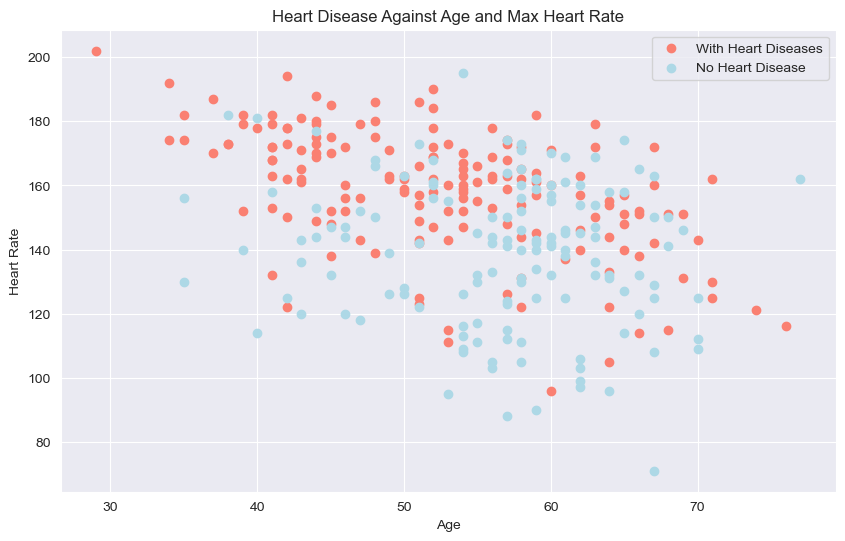

In [19]:
# Create a figure with two plots for our independent variables
plt.figure(figsize=(10, 6))

# Scatter plot with positive examples only
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c='salmon')

# Scatter plat with zero examples only
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c='lightblue')

plt.title('Heart Disease Against Age and Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Heart Rate')
plt.legend(['With Heart Diseases', 'No Heart Disease'])

plt.show()

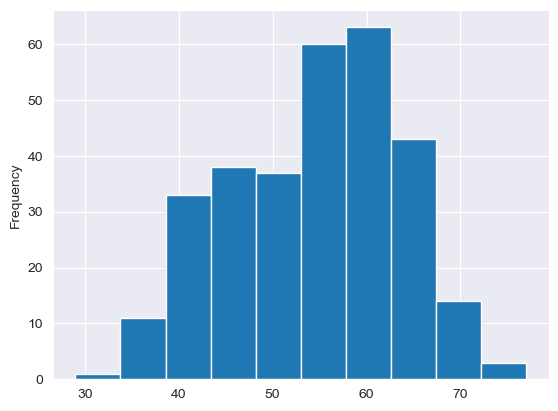

In [20]:
# View the distribution of age with a histogram
df.age.plot.hist()

plt.show()

### Heart Disease Frequency for Chest Pain (Type)

Remember our data dictionary values for chest pain

cp - chest pain type

    - Typical angina: chest pain related to decreased blood supply to the heart
    - Atypical angina: chest pain not related to the heart
    - Non-anginal: typical esophageal spasms (not heart related)
    - Asymptomatic: chest pain not showing signs of disease


In [21]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


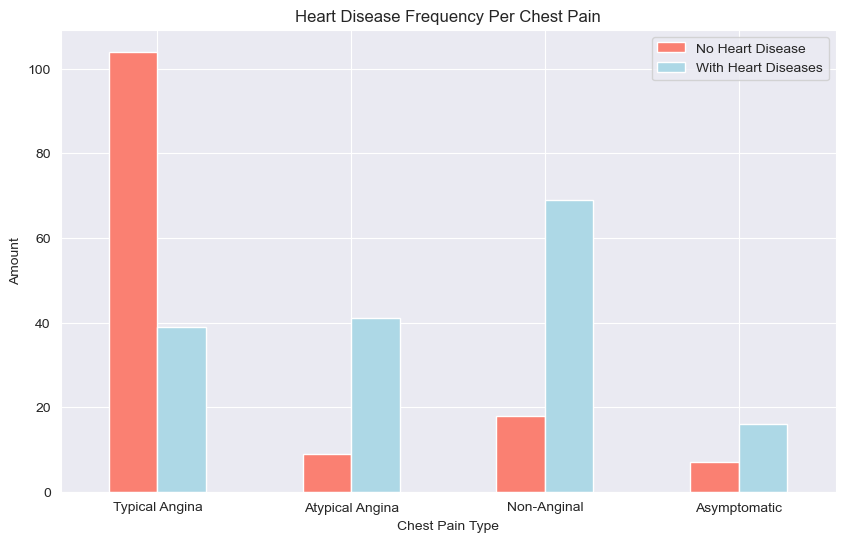

In [22]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind='bar',
                                   figsize=(10, 6),
                                   color=['salmon', 'lightblue'])

# Add some communication
plt.title('Heart Disease Frequency Per Chest Pain')
plt.xlabel('Chest Pain Type')
plt.ylabel('Amount')
plt.legend(['No Heart Disease', 'With Heart Diseases'])
plt.xticks(rotation=0,
           labels=['Typical Angina',
                   'Atypical Angina',
                   'Non-Anginal',
                   'Asymptomatic',],
           ticks=[0, 1, 2, 3])
plt.show()

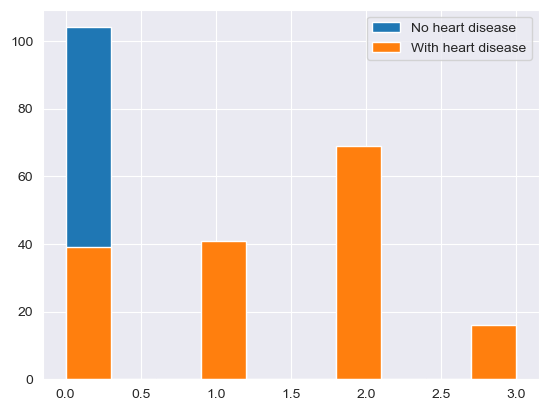

In [23]:
plt.hist(df[df['target'] == 0]['cp'], label='No heart disease')
plt.hist(df[df['target'] == 1]['cp'], label='With heart disease')
plt.legend()

plt.show()

In [24]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [25]:
# Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


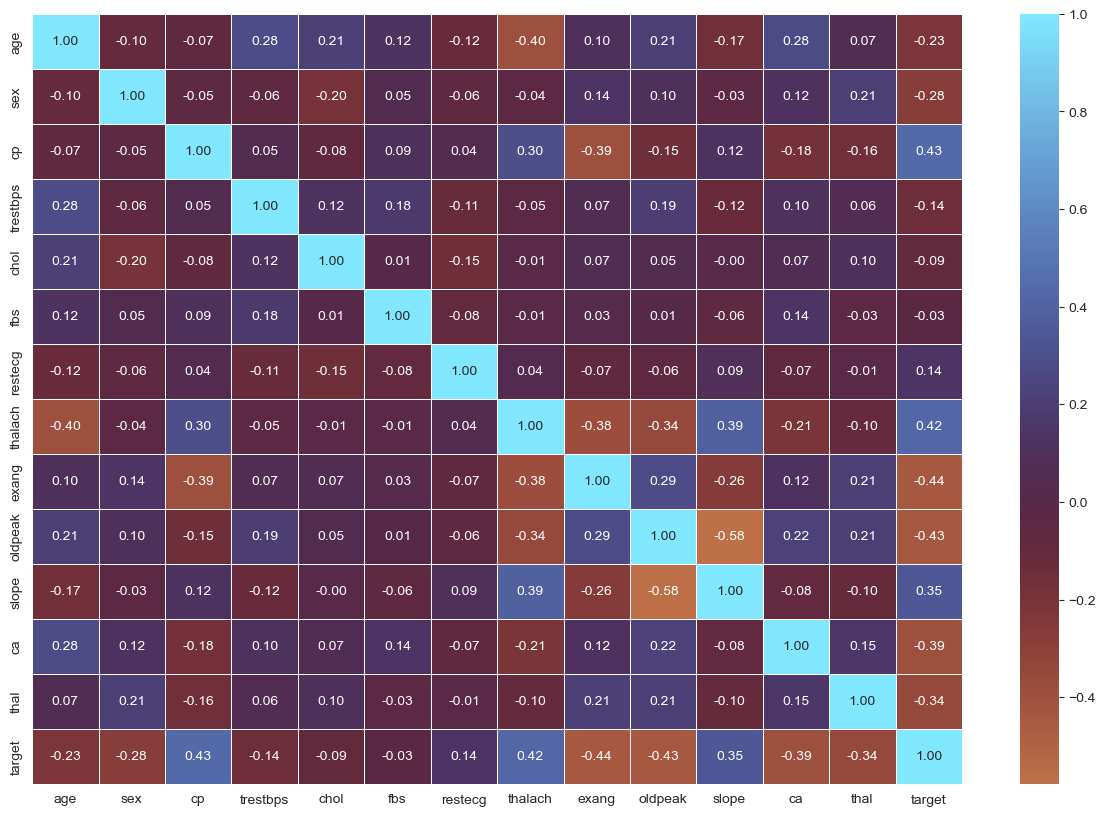

In [26]:
# Let's make our correlation matrix a little prettier
correlation_matrix = df.corr()

# Create a figure
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(
    correlation_matrix,
    annot=True, # annotate the heat map
    linewidths=0.5,
    fmt='.2f', # two digits after decimal point
    # cmap='YlGnBu', # yellow-green-blue color map
    cmap='managua', # diverging color map
    # See [Matplotlib color maps](https://matplotlib.org/stable/users/explain/colors/colormaps.html)
    center=0, # The data is **not** symmetric around 0 but it could be
)

plt.show()

9. exang: exercise-induced angina (1 = yes; 0 = no)

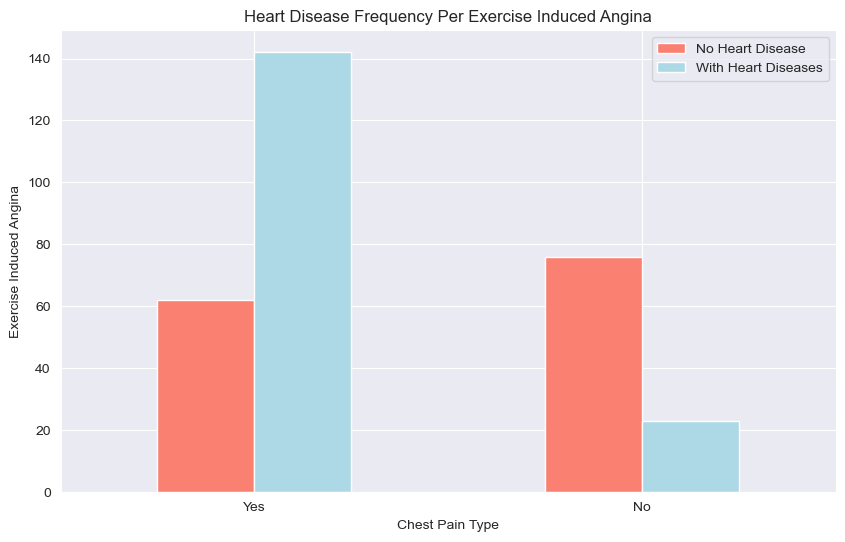

In [27]:
# Let's look at the relationship between `exang` and `target`
# Oun matrix indicates they are negatively correlated.
pd.crosstab(df.exang, df.target).plot(
    kind='bar',
    figsize=(10, 6),
    color=['salmon', 'lightblue']
)

# Add some communication
plt.title('Heart Disease Frequency Per Exercise Induced Angina')
plt.xlabel('Chest Pain Type')
plt.ylabel('Exercise Induced Angina')
plt.legend(['No Heart Disease', 'With Heart Diseases'])
plt.xticks(rotation=0,
           labels=['Yes',
                   'No',],
           ticks=[0, 1])
plt.show()

## 5.0 Modelling

In [28]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [29]:
# Initialize our random number generator for reproducibility
rng = np.random.default_rng(seed=42)

In [30]:
# Split data into features (X) and labels (y)
X = df.drop('target', axis=1)
y= df['target']

In [31]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [32]:
y.head(), y.tail()

(0    1
 1    1
 2    1
 3    1
 4    1
 Name: target, dtype: int64,
 298    0
 299    0
 300    0
 301    0
 302    0
 Name: target, dtype: int64)

In [33]:
# Then split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=rng.integers(np.iinfo(np.int32).max)
)

In [34]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
109,50,0,0,110,254,0,0,159,0,0.0,2,0,2
238,77,1,0,125,304,0,0,162,1,0.0,2,3,2
69,62,0,0,124,209,0,1,163,0,0.0,2,0,2
70,54,1,2,120,258,0,0,147,0,0.4,1,0,3
96,62,0,0,140,394,0,0,157,0,1.2,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
116,41,1,2,130,214,0,0,168,0,2.0,1,0,2
262,53,1,0,123,282,0,1,95,1,2.0,1,2,3
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2


In [35]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
281,52,1,0,128,204,1,1,156,1,1.0,1,0,0
48,53,0,2,128,216,0,0,115,0,0.0,2,0,0
47,47,1,2,138,257,0,0,156,0,0.0,2,0,2
208,49,1,2,120,188,0,1,139,0,2.0,1,3,3
112,64,0,2,140,313,0,1,133,0,0.2,2,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,63,0,0,108,269,0,1,169,1,1.8,1,2,2
72,29,1,1,130,204,0,0,202,0,0.0,2,0,2
20,59,1,0,135,234,0,1,161,0,0.5,1,0,3
215,43,0,0,132,341,1,0,136,1,3.0,1,0,3


In [36]:
y_train

109    1
238    0
69     1
70     1
96     1
      ..
188    0
116    1
262    0
132    1
15     1
Name: target, Length: 242, dtype: int64

In [37]:
y_test

281    0
48     1
47     1
208    0
112    1
      ..
263    0
72     1
20     1
215    0
141    1
Name: target, Length: 61, dtype: int64

Now that we've got our data split into training and test sets,
it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

What learning model(s) should we use?

Let's consult our [Online machine learning model map](https://scikit-learn.org/stable/machine_learning_map.html).

Our map seems to recommend (the video, actually):
- K-neighbors classifier
- SVC ensemble classifier

But we're missing one:
- Logistic Regression

We're going to try three different machine learning models

1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Random Forest Classifier

In [39]:
# Put models in a dictionary
models = {
    'Logistic Regression': LogisticRegression(
        random_state=rng.integers(np.iinfo(np.int32).max),
    ),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(
        random_state=rng.integers(np.iinfo(np.int32).max),
    ),
}

In [41]:
# Create a function to fit and score models
def evaluate_models(model, X_train, X_test, y_train, y_test):
    """
    Fit and evaluate specified model
    :param model: A sklearn model
    :param X_train: training data (no labels)
    :param X_test: testing data (no labels)
    :param y_train: training labels
    :param y_test: test labels
    """
    model.fit(X_train, y_train)
    result = model.score(X_test, y_test)
    return result

In [43]:
# Evaluate each model

# Capture the score for each model
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fit and evaluate specified model
    :param models: A dictionary of model names and models
    :param X_train: training data (no labels)
    :param X_test: testing data (no labels)
    :param y_train: training labels
    :param y_test: test labels
    """
    return {
        name: evaluate_models(model, X_train, X_test, y_train, y_test)
        for name, model in models.items()
    }

In [45]:
fit_and_score(models, X_train, X_test, y_train, y_test)

/opt/homebrew/Caskroom/miniconda/base/envs/heart-disease-project/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8032786885245902,
 'KNN': 0.5901639344262295,
 'Random Forest': 0.7540983606557377}